# ============================================================
# NOTEBOOK: match_dos_v2.ipynb
# DoS — Matching entre CIC, Nemea, Tstat y Tshark
# ============================================================
#
# PARTICULARIDADES DoS:
#   1. Ficheros muy grandes (CIC ~4.3 GB, Nemea ~608 MB,
#      Tshark ~654 MB, Tstat ~95 MB) → estrategia dos fases:
#
#      FASE 1 — MATCHING: usecols para cargar solo las columnas
#               necesarias para construir claves. Reduce el uso
#               de RAM >90% respecto a cargar el CSV completo.
#
#      FASE 2 — EXTRACCIÓN: chunksize para releer los ficheros
#               originales en trozos y extraer solo las filas
#               que pertenecen a base_4. Nunca se carga el CSV
#               entero en RAM.
#
#   2. Nemea: 4 CSVs separados → se concatenan (igual que CIC)
#   3. Nemea: IPs sin puntos → reconstruir_ip
#   4. Nemea: timestamps con coma decimal
#   5. CIC / Tstat / Tshark: múltiples CSVs en carpeta → glob
#   6. Etiqueta unificada a 'DoS'
# ============================================================

In [2]:
# ============================================================
# CELDA 0 — IMPORTS GLOBALES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import gc
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Tamaño de chunk para la fase de extracción
CHUNKSIZE = 200_000

print('\u2713 Imports OK')
print(f'  pandas:  {pd.__version__}')
print(f'  numpy:   {np.__version__}')
print(f'  CHUNKSIZE para extracción: {CHUNKSIZE:,} filas')

✓ Imports OK
  pandas:  2.2.0
  numpy:   1.26.4
  CHUNKSIZE para extracción: 200,000 filas


In [3]:
# ============================================================
# CELDA 0.1 — FUNCIÓN reconstruir_ip
# ============================================================

def reconstruir_ip(ip):
    if pd.isna(ip):
        return ip
    s = str(ip).strip()
    if '.' in s:
        return s
    if not s.isdigit():
        return s
    resultados = []
    def backtrack(resto, partes):
        if len(partes) == 4:
            if resto == '':
                resultados.append(partes[:])
            return
        for i in range(1, 4):
            if i > len(resto):
                break
            trozo = resto[:i]
            if len(trozo) > 1 and trozo[0] == '0':
                continue
            if 0 <= int(trozo) <= 255:
                partes.append(trozo)
                backtrack(resto[i:], partes)
                partes.pop()
    backtrack(s, [])
    return '.'.join(resultados[0]) if resultados else s

print('Test reconstruir_ip:')
print(f"  '192168001001' \u2192 {reconstruir_ip('192168001001')}")
print(f"  '192.168.0.1'  \u2192 {reconstruir_ip('192.168.0.1')}  (ya tiene puntos)")

Test reconstruir_ip:
  '192168001001' → 192168001001
  '192.168.0.1'  → 192.168.0.1  (ya tiene puntos)


# CICFlowMeter
## FASE 1: carga solo columnas clave (usecols)

In [4]:
# ============================================================
# CELDA 1.1 — FASE 1: CARGA CIC (solo columnas clave)
# usecols reduce >90% el uso de RAM respecto al CSV completo
# ============================================================

RUTA_CIC = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/DoS')
print(f'Ruta CIC: {RUTA_CIC}')
print(f'Existe:   {RUTA_CIC.exists()}')
print()

csv_files_cic = sorted(RUTA_CIC.glob('*.csv'))
print(f'CSVs encontrados: {len(csv_files_cic)}')
if not csv_files_cic:
    raise FileNotFoundError(f'No se encontraron CSVs en: {RUTA_CIC}')

# Solo las columnas necesarias para construir las claves
COLS_CIC_KEY = ['Src IP', 'Src Port', 'Dst IP', 'Dst Port',
                'Protocol', 'Timestamp', 'Flow Duration']

dfs_cic = []
for f in csv_files_cic:
    df_temp = pd.read_csv(f, usecols=COLS_CIC_KEY, low_memory=False)
    df_temp['_archivo'] = f.stem
    dfs_cic.append(df_temp)
    print(f'  \u2713 {f.name:50s} \u2192 {len(df_temp):>8,} filas')

df_cic_keys = pd.concat(dfs_cic, ignore_index=True)
del dfs_cic
gc.collect()

print()
print(f'Shape CIC (solo cols clave): {df_cic_keys.shape}')
print(f'RAM estimada:                {df_cic_keys.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Ruta CIC: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/DoS
Existe:   True

CSVs encontrados: 5
  ✓ DoS-HTTP_Flood.pcap_Flow.csv                       →  932,513 filas
  ✓ DoS-HTTP_Flood1.pcap_Flow.csv                      →  710,231 filas
  ✓ DoS-SYN_Flood.pcap_Flow.csv                        → 3,990,181 filas
  ✓ DoS-TCP_Flood.pcap_Flow.csv                        → 1,637,349 filas
  ✓ DoS-UDP_Flood.pcap_Flow.csv                        →  934,001 filas

Shape CIC (solo cols clave): (8204275, 8)
RAM estimada:                2770.1 MB


In [5]:
# ============================================================
# CELDA 1.2 — LIMPIEZA Y NORMALIZACIÓN CIC (cols clave)
# ============================================================

df_cic_keys['Timestamp'] = (
    df_cic_keys['Timestamp'].astype(str)
    .str.replace(' p. m.', ' PM', regex=False)
    .str.replace(' a. m.', ' AM', regex=False)
    .str.strip()
)
df_cic_keys['Timestamp'] = pd.to_datetime(
    df_cic_keys['Timestamp'], format='%d/%m/%Y %I:%M:%S %p', errors='coerce'
)

nat_count = df_cic_keys['Timestamp'].isna().sum()
print(f'NaT en Timestamp: {nat_count}')
if nat_count > 0:
    df_cic_keys = df_cic_keys.dropna(subset=['Timestamp']).reset_index(drop=True)

df_cic_keys['Protocol']      = pd.to_numeric(df_cic_keys['Protocol'],      errors='coerce').fillna(0).astype(int)
df_cic_keys['Src Port']      = pd.to_numeric(df_cic_keys['Src Port'],      errors='coerce').fillna(0).astype(int)
df_cic_keys['Dst Port']      = pd.to_numeric(df_cic_keys['Dst Port'],      errors='coerce').fillna(0).astype(int)
df_cic_keys['Flow Duration'] = pd.to_numeric(df_cic_keys['Flow Duration'], errors='coerce')

df_cic_keys['time_sec']    = df_cic_keys['Timestamp'].dt.floor('s')
df_cic_keys['flow_dur_ms'] = (df_cic_keys['Flow Duration'] / 1000).round().astype('Int64')

df_cic_keys['key_base'] = list(zip(
    df_cic_keys['Src IP'].astype(str),
    df_cic_keys['Src Port'].astype(str),
    df_cic_keys['Dst IP'].astype(str),
    df_cic_keys['Dst Port'].astype(str),
    df_cic_keys['Protocol'].astype(str),
    df_cic_keys['time_sec'].astype(str)
))
df_cic_keys['key_exact'] = list(zip(
    df_cic_keys['Src IP'].astype(str),
    df_cic_keys['Src Port'].astype(str),
    df_cic_keys['Dst IP'].astype(str),
    df_cic_keys['Dst Port'].astype(str),
    df_cic_keys['Protocol'].astype(str),
    df_cic_keys['time_sec'].astype(str),
    df_cic_keys['flow_dur_ms'].astype(str)
))

cic_keys_base  = set(df_cic_keys['key_base'])
cic_keys_exact = set(df_cic_keys['key_exact'])

print(f'Shape CIC limpio:    {df_cic_keys.shape}')
print(f'Claves base únicas:  {len(cic_keys_base):,}')
print(f'\nRango temporal CIC:')
print(f'  Min: {df_cic_keys["Timestamp"].min()}')
print(f'  Max: {df_cic_keys["Timestamp"].max()}')
print(f'\nDistribución por protocolo:')
print(df_cic_keys['Protocol'].value_counts().to_string())
print(f'\nDistribución por subtipo:')
print(df_cic_keys['_archivo'].value_counts().to_string())

NaT en Timestamp: 0
Shape CIC limpio:    (8204275, 12)
Claves base únicas:  8,078,797

Rango temporal CIC:
  Min: 2022-07-22 16:41:31
  Max: 2022-08-10 15:19:33

Distribución por protocolo:
Protocol
6     7239632
17     963061
0        1582

Distribución por subtipo:
_archivo
DoS-SYN_Flood.pcap_Flow      3990181
DoS-TCP_Flood.pcap_Flow      1637349
DoS-UDP_Flood.pcap_Flow       934001
DoS-HTTP_Flood.pcap_Flow      932513
DoS-HTTP_Flood1.pcap_Flow     710231


In [6]:
# ============================================================
# CELDA 1.3 — ANÁLISIS DE COLISIONES CIC
# ============================================================

conteo          = df_cic_keys.groupby('key_base').size()
total_claves    = len(conteo)
claves_unicas   = (conteo == 1).sum()
claves_colision = (conteo > 1).sum()
flujos_colision = conteo[conteo > 1].sum()
pct_colision    = round(claves_colision / total_claves * 100, 2)

print('=' * 60)
print('ANÁLISIS DE COLISIONES CIC — DoS')
print('=' * 60)
print(f'  Total filas:                 {len(df_cic_keys):,}')
print(f'  Total claves base únicas:    {total_claves:,}')
print(f'  Claves sin colisión:         {claves_unicas:,}  ({round(claves_unicas/total_claves*100,2)}%)')
print(f'  Claves con colisión:         {claves_colision:,}  ({pct_colision}%)')
print(f'  Flujos afectados:            {flujos_colision:,}')
print()
if pct_colision < 1:
    print(f'  \u2192 \u2713 SEGURO ({pct_colision}% colisiones)')
elif pct_colision < 5:
    print(f'  \u2192 ~ ACEPTABLE ({pct_colision}% colisiones)')
else:
    print(f'  \u2192 \u2717 RIESGO ({pct_colision}% colisiones)')

ANÁLISIS DE COLISIONES CIC — DoS
  Total filas:                 8,204,275
  Total claves base únicas:    8,078,797
  Claves sin colisión:         8,012,621  (99.18%)
  Claves con colisión:         66,176  (0.82%)
  Flujos afectados:            191,654

  → ✓ SEGURO (0.82% colisiones)


# NEMEA
## FASE 1: carga solo columnas clave (usecols) — 4 CSVs

In [7]:
# ============================================================
# CELDA 2.1 — FASE 1: CARGA NEMEA (4 CSVs, solo cols clave)
# DoS: Nemea está dividido en 4 CSVs por tamaño
# ============================================================

RUTA_NEMEA = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/DoS/DoS')
print(f'Ruta Nemea: {RUTA_NEMEA}')
print(f'Existe:     {RUTA_NEMEA.exists()}')
print()

csv_files_nemea = sorted(RUTA_NEMEA.glob('*.csv'))
print(f'CSVs encontrados: {len(csv_files_nemea)}')
for f in csv_files_nemea:
    print(f'  {f.name}')

# Leer cabecera del primer fichero para detectar columna de etiqueta
header_nemea = pd.read_csv(csv_files_nemea[0], nrows=0)
col_etiqueta_nemea = header_nemea.columns[-1]
print(f'\nColumna de etiqueta detectada: \'{col_etiqueta_nemea}\'')

COLS_NEMEA_KEY = [
    'ipaddr SRC_IP', 'uint16 SRC_PORT',
    'ipaddr DST_IP', 'uint16 DST_PORT',
    'uint8 PROTOCOL',
    'time TIME_FIRST', 'time TIME_LAST'
]

dfs_nemea = []
for f in csv_files_nemea:
    df_temp = pd.read_csv(f, usecols=COLS_NEMEA_KEY, low_memory=False)
    dfs_nemea.append(df_temp)
    print(f'  \u2713 {f.name:50s} \u2192 {len(df_temp):>8,} filas')

df_nemea_keys = pd.concat(dfs_nemea, ignore_index=True)
del dfs_nemea
gc.collect()

print()
print(f'Shape Nemea (solo cols clave): {df_nemea_keys.shape}')
print(f'RAM estimada:                  {df_nemea_keys.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Ruta Nemea: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/DoS/DoS
Existe:     True

CSVs encontrados: 4
  DoS_HTTP_Nemea.csv
  DoS_SYN_Nemea.csv
  DoS_TCP_Nemea.csv
  DoS_UDP_Nemea.csv

Columna de etiqueta detectada: 'LABEL'
  ✓ DoS_HTTP_Nemea.csv                                 →  282,398 filas
  ✓ DoS_SYN_Nemea.csv                                  →  138,860 filas
  ✓ DoS_TCP_Nemea.csv                                  →  131,330 filas
  ✓ DoS_UDP_Nemea.csv                                  →   79,472 filas

Shape Nemea (solo cols clave): (632060, 7)
RAM estimada:                  210.6 MB


In [8]:
# ============================================================
# CELDA 2.2 — LIMPIEZA Y NORMALIZACIÓN NEMEA
# ============================================================

col_src_ip   = 'ipaddr SRC_IP'
col_dst_ip   = 'ipaddr DST_IP'
col_src_port = 'uint16 SRC_PORT'
col_dst_port = 'uint16 DST_PORT'
col_protocol = 'uint8 PROTOCOL'
col_t_first  = 'time TIME_FIRST'
col_t_last   = 'time TIME_LAST'

df_nemea_keys[col_src_ip] = df_nemea_keys[col_src_ip].astype(str).str.strip()
df_nemea_keys[col_dst_ip] = df_nemea_keys[col_dst_ip].astype(str).str.strip()

df_nemea_keys['SRC_IP_norm'] = df_nemea_keys[col_src_ip].apply(reconstruir_ip)
df_nemea_keys['DST_IP_norm'] = df_nemea_keys[col_dst_ip].apply(reconstruir_ip)

n_src = (~df_nemea_keys[col_src_ip].str.contains('.', regex=False)).sum()
n_dst = (~df_nemea_keys[col_dst_ip].str.contains('.', regex=False)).sum()
print(f'IPs SRC sin punto: {n_src:,}  |  IPs DST sin punto: {n_dst:,}')

df_nemea_keys['TIME_FIRST_limpio'] = df_nemea_keys[col_t_first].astype(str).str.replace(',', '.', regex=False)
df_nemea_keys['TIME_LAST_limpio']  = df_nemea_keys[col_t_last].astype(str).str.replace(',', '.', regex=False)

df_nemea_keys['TIME_FIRST_dt'] = pd.to_datetime(
    df_nemea_keys['TIME_FIRST_limpio'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce'
)
df_nemea_keys['TIME_LAST_dt'] = pd.to_datetime(
    df_nemea_keys['TIME_LAST_limpio'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce'
)

df_nemea_keys['TIME_FIRST_utc2'] = df_nemea_keys['TIME_FIRST_dt'] + pd.Timedelta(hours=2)
df_nemea_keys['TIME_LAST_utc2']  = df_nemea_keys['TIME_LAST_dt']  + pd.Timedelta(hours=2)

df_nemea_keys['flow_dur_us'] = (
    (df_nemea_keys['TIME_LAST_utc2'] - df_nemea_keys['TIME_FIRST_utc2'])
    .dt.total_seconds() * 1_000_000
).round().astype('Int64')
df_nemea_keys['flow_dur_ms'] = (df_nemea_keys['flow_dur_us'] / 1000).round().astype('Int64')

df_nemea_keys[col_protocol] = pd.to_numeric(
    df_nemea_keys[col_protocol], errors='coerce'
).fillna(0).astype(int)

df_nemea_keys['time_sec'] = df_nemea_keys['TIME_FIRST_utc2'].dt.floor('s')

print(f'\nShape Nemea: {df_nemea_keys.shape}')
print(f'NaT TIME_FIRST: {df_nemea_keys["TIME_FIRST_dt"].isna().sum():,}')
print(f'\nRango temporal Nemea (UTC+2):')
print(f'  Min: {df_nemea_keys["TIME_FIRST_utc2"].min()}')
print(f'  Max: {df_nemea_keys["TIME_LAST_utc2"].max()}')
print(f'\nRango CIC:')
print(f'  Min: {df_cic_keys["Timestamp"].min()}')
print(f'  Max: {df_cic_keys["Timestamp"].max()}')

IPs SRC sin punto: 1,068  |  IPs DST sin punto: 1,068

Shape Nemea: (632060, 18)
NaT TIME_FIRST: 0

Rango temporal Nemea (UTC+2):
  Min: 2022-07-22 16:49:00.381021
  Max: 2022-08-09 20:42:00.063538

Rango CIC:
  Min: 2022-07-22 16:41:31
  Max: 2022-08-10 15:19:33


In [9]:
# ============================================================
# CELDA 2.3 — KEY BASE Y MATCHING CIC ∩ NEMEA
# ============================================================

df_nemea_keys['key_base_dir'] = list(zip(
    df_nemea_keys['SRC_IP_norm'].astype(str),
    df_nemea_keys[col_src_port].astype(str),
    df_nemea_keys['DST_IP_norm'].astype(str),
    df_nemea_keys[col_dst_port].astype(str),
    df_nemea_keys[col_protocol].astype(str),
    df_nemea_keys['time_sec'].astype(str)
))
df_nemea_keys['key_base_inv'] = list(zip(
    df_nemea_keys['DST_IP_norm'].astype(str),
    df_nemea_keys[col_dst_port].astype(str),
    df_nemea_keys['SRC_IP_norm'].astype(str),
    df_nemea_keys[col_src_port].astype(str),
    df_nemea_keys[col_protocol].astype(str),
    df_nemea_keys['time_sec'].astype(str)
))
df_nemea_keys['key_exact_dir'] = list(zip(
    df_nemea_keys['SRC_IP_norm'].astype(str),
    df_nemea_keys[col_src_port].astype(str),
    df_nemea_keys['DST_IP_norm'].astype(str),
    df_nemea_keys[col_dst_port].astype(str),
    df_nemea_keys[col_protocol].astype(str),
    df_nemea_keys['time_sec'].astype(str),
    df_nemea_keys['flow_dur_ms'].astype(str)
))
df_nemea_keys['key_exact_inv'] = list(zip(
    df_nemea_keys['DST_IP_norm'].astype(str),
    df_nemea_keys[col_dst_port].astype(str),
    df_nemea_keys['SRC_IP_norm'].astype(str),
    df_nemea_keys[col_src_port].astype(str),
    df_nemea_keys[col_protocol].astype(str),
    df_nemea_keys['time_sec'].astype(str),
    df_nemea_keys['flow_dur_ms'].astype(str)
))

nemea_base_dir  = set(df_nemea_keys['key_base_dir'])
nemea_base_inv  = set(df_nemea_keys['key_base_inv'])
nemea_exact_dir = set(df_nemea_keys['key_exact_dir'])
nemea_exact_inv = set(df_nemea_keys['key_exact_inv'])

match_nemea_base  = cic_keys_base  & (nemea_base_dir  | nemea_base_inv)
match_nemea_exact = cic_keys_exact & (nemea_exact_dir | nemea_exact_inv)

print('=' * 60)
print('MATCHING CIC \u2229 NEMEA — DoS')
print('=' * 60)
print(f'  CIC total flujos:            {len(df_cic_keys):,}')
print(f'  Nemea total flujos:          {len(df_nemea_keys):,}')
print(f'  CIC claves base únicas:      {len(cic_keys_base):,}')
print(f'  Nemea claves base únicas:    {len(nemea_base_dir):,}')
print()
print(f'  Match BASE (sin duración):   {len(match_nemea_base):,}')
print(f'  Match EXACTO (con dur. ms):  {len(match_nemea_exact):,}')
print(f'  Diferencia:                  {len(match_nemea_base) - len(match_nemea_exact):,}')
print()
print(f'  % match base sobre CIC:      {round(len(match_nemea_base)/len(cic_keys_base)*100,2)}%')
print(f'  % match exacto sobre CIC:    {round(len(match_nemea_exact)/len(cic_keys_base)*100,2)}%')

MATCHING CIC ∩ NEMEA — DoS
  CIC total flujos:            8,204,275
  Nemea total flujos:          632,060
  CIC claves base únicas:      8,078,797
  Nemea claves base únicas:    632,046

  Match BASE (sin duración):   552,828
  Match EXACTO (con dur. ms):  160,882
  Diferencia:                  391,946

  % match base sobre CIC:      6.84%
  % match exacto sobre CIC:    1.99%


# TSTAT
## FASE 1: carga solo columnas clave (usecols)

In [10]:
# ============================================================
# CELDA 3.1 — FASE 1: CARGA TSTAT (solo cols clave)
# ============================================================

RUTA_TSTAT = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTstat/CSV/DoS')
print(f'Ruta Tstat: {RUTA_TSTAT}')
print(f'Existe:     {RUTA_TSTAT.exists()}')
print()

csv_files_tstat = sorted(RUTA_TSTAT.glob('*.csv'))
print(f'CSVs encontrados: {len(csv_files_tstat)}')

# Leer cabecera para confirmar columnas disponibles
header_tstat = pd.read_csv(csv_files_tstat[0], nrows=0)
print(f'Columnas disponibles: {header_tstat.columns.tolist()[:12]} ...')

# TCP: first, durat, c_ip, c_port, s_ip, s_port, protocolo
# UDP: c_first_abs, c_durat, s_durat, c_ip, c_port, s_ip, s_port, protocolo
COLS_TSTAT_KEY = ['c_ip', 'c_port', 's_ip', 's_port', 'protocolo',
                  'first', 'durat', 'c_first_abs', 'c_durat', 's_durat']

dfs_tstat = []
for f in csv_files_tstat:
    cols_disp = pd.read_csv(f, nrows=0).columns.tolist()
    cols_usar  = [c for c in COLS_TSTAT_KEY if c in cols_disp]
    df_temp = pd.read_csv(f, usecols=cols_usar, low_memory=False)
    dfs_tstat.append(df_temp)
    print(f'  \u2713 {f.name:40s} \u2192 {len(df_temp):>8,} filas')

df_tstat_keys = pd.concat(dfs_tstat, ignore_index=True)
del dfs_tstat
gc.collect()

print()
print(f'Shape Tstat (solo cols clave): {df_tstat_keys.shape}')
print(f'RAM estimada:                  {df_tstat_keys.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\nDistribución por protocolo:')
print(df_tstat_keys['protocolo'].value_counts().to_string())

Ruta Tstat: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTstat/CSV/DoS
Existe:     True

CSVs encontrados: 4
Columnas disponibles: ['c_iscrypto', 's_iscrypto', 's_pkts_all', 'c_isint', 's_isint', 'c_port', 'fqdn', 's_ip', 'c_pkts_all', 'c_ip', 'c_bytes_all', 's_port'] ...
  ✓ DoS-HTTP_Flood.csv                       →   63,308 filas
  ✓ DoS-SYN_Flood.csv                        →   80,531 filas
  ✓ DoS-TCP_Flood.csv                        →      959 filas
  ✓ DoS-UDP_Flood.csv                        →   67,043 filas

Shape Tstat (solo cols clave): (211841, 10)
RAM estimada:                  54.9 MB

Distribución por protocolo:
protocolo
TCP    132917
UDP     78924


In [11]:
# ============================================================
# CELDA 3.2 — LIMPIEZA TCP/UDP Y CONSTRUCCIÓN DE CLAVES TSTAT
# ============================================================

df_tcp_k = df_tstat_keys[df_tstat_keys['protocolo'] == 'TCP'].copy()
df_udp_k = df_tstat_keys[df_tstat_keys['protocolo'] == 'UDP'].copy()
print(f'TCP total: {len(df_tcp_k):,}  | UDP total: {len(df_udp_k):,}')

# ── TCP
df_tcp_k['first'] = pd.to_numeric(df_tcp_k['first'], errors='coerce')
df_tcp_k = df_tcp_k[df_tcp_k['first'] > 0].copy()
df_tcp_k['first_dt']   = pd.to_datetime(df_tcp_k['first'], unit='ms', errors='coerce')
df_tcp_k['first_utc2'] = df_tcp_k['first_dt'] + pd.Timedelta(hours=2)
df_tcp_k['flow_dur_ms'] = pd.to_numeric(df_tcp_k['durat'], errors='coerce').round().astype('Int64')
df_tcp_k['proto_num']   = 6
df_tcp_k['time_sec']    = df_tcp_k['first_utc2'].dt.floor('s')
print(f'TCP válidos: {len(df_tcp_k):,}')

# ── UDP
df_udp_k['c_first_abs'] = pd.to_numeric(df_udp_k['c_first_abs'], errors='coerce')
df_udp_k = df_udp_k[df_udp_k['c_first_abs'] > 0].copy()
df_udp_k['first_dt']   = pd.to_datetime(df_udp_k['c_first_abs'], unit='ms', errors='coerce')
df_udp_k['first_utc2'] = df_udp_k['first_dt'] + pd.Timedelta(hours=2)
df_udp_k['c_durat']    = pd.to_numeric(df_udp_k['c_durat'], errors='coerce').fillna(0)
df_udp_k['s_durat']    = pd.to_numeric(df_udp_k['s_durat'], errors='coerce').fillna(0)
df_udp_k['flow_dur_ms'] = df_udp_k[['c_durat','s_durat']].max(axis=1).round().astype('Int64')
df_udp_k['proto_num']   = 17
df_udp_k['time_sec']    = df_udp_k['first_utc2'].dt.floor('s')
print(f'UDP válidos: {len(df_udp_k):,}')

# Unificar solo cols de clave
cols_unif = ['c_ip','c_port','s_ip','s_port','proto_num','time_sec','flow_dur_ms']
df_tstat_base_k = pd.concat([
    df_tcp_k[cols_unif],
    df_udp_k[cols_unif]
], ignore_index=True)

# Claves
df_tstat_base_k['key_base_dir'] = list(zip(
    df_tstat_base_k['c_ip'].astype(str), df_tstat_base_k['c_port'].astype(str),
    df_tstat_base_k['s_ip'].astype(str), df_tstat_base_k['s_port'].astype(str),
    df_tstat_base_k['proto_num'].astype(str), df_tstat_base_k['time_sec'].astype(str)
))
df_tstat_base_k['key_base_inv'] = list(zip(
    df_tstat_base_k['s_ip'].astype(str), df_tstat_base_k['s_port'].astype(str),
    df_tstat_base_k['c_ip'].astype(str), df_tstat_base_k['c_port'].astype(str),
    df_tstat_base_k['proto_num'].astype(str), df_tstat_base_k['time_sec'].astype(str)
))

df_tstat_dur_k = df_tstat_base_k[df_tstat_base_k['flow_dur_ms'] > 0].copy()
df_tstat_dur_k['key_exact_dir'] = list(zip(
    df_tstat_dur_k['c_ip'].astype(str), df_tstat_dur_k['c_port'].astype(str),
    df_tstat_dur_k['s_ip'].astype(str), df_tstat_dur_k['s_port'].astype(str),
    df_tstat_dur_k['proto_num'].astype(str), df_tstat_dur_k['time_sec'].astype(str),
    df_tstat_dur_k['flow_dur_ms'].astype(str)
))
df_tstat_dur_k['key_exact_inv'] = list(zip(
    df_tstat_dur_k['s_ip'].astype(str), df_tstat_dur_k['s_port'].astype(str),
    df_tstat_dur_k['c_ip'].astype(str), df_tstat_dur_k['c_port'].astype(str),
    df_tstat_dur_k['proto_num'].astype(str), df_tstat_dur_k['time_sec'].astype(str),
    df_tstat_dur_k['flow_dur_ms'].astype(str)
))

tstat_base_keys  = set(df_tstat_base_k['key_base_dir']) | set(df_tstat_base_k['key_base_inv'])
tstat_exact_keys = set(df_tstat_dur_k['key_exact_dir']) | set(df_tstat_dur_k['key_exact_inv'])

match_tstat_base  = cic_keys_base  & tstat_base_keys
match_tstat_exact = cic_keys_exact & tstat_exact_keys

print('=' * 60)
print('MATCHING CIC \u2229 TSTAT — DoS')
print('=' * 60)
print(f'  Tstat total flujos:          {len(df_tstat_base_k):,}')
print(f'  Tstat con duración > 0:      {len(df_tstat_dur_k):,}')
print(f'  Match BASE:                  {len(match_tstat_base):,}')
print(f'  Match EXACTO:                {len(match_tstat_exact):,}')
print(f'  % match base sobre CIC:      {round(len(match_tstat_base)/len(cic_keys_base)*100,2)}%')
print(f'  % match exacto sobre CIC:    {round(len(match_tstat_exact)/len(cic_keys_base)*100,2)}%')

TCP total: 132,917  | UDP total: 78,924
TCP válidos: 132,917
UDP válidos: 78,924
MATCHING CIC ∩ TSTAT — DoS
  Tstat total flujos:          211,841
  Tstat con duración > 0:      200,756
  Match BASE:                  206,854
  Match EXACTO:                115,977
  % match base sobre CIC:      2.56%
  % match exacto sobre CIC:    1.44%


# TSHARK
## FASE 1: carga solo columnas clave (usecols)

In [12]:
# ============================================================
# CELDA 4.1 — FASE 1: CARGA TSHARK (solo cols clave)
# ============================================================

RUTA_TSHARK = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTshark_2/Csv/DoS')
print(f'Ruta Tshark: {RUTA_TSHARK}')
print(f'Existe:      {RUTA_TSHARK.exists()}')
print()

csv_files_tshark = sorted(RUTA_TSHARK.glob('*.csv'))
print(f'CSVs encontrados: {len(csv_files_tshark)}')

COLS_TSHARK_KEY = ['src_ip', 'src_port', 'dst_ip', 'dst_port',
                   'proto_num', 'start_epoch', 'flow_duration_s']

dfs_tshark = []
for f in csv_files_tshark:
    df_temp = pd.read_csv(f, usecols=COLS_TSHARK_KEY, low_memory=False)
    dfs_tshark.append(df_temp)
    print(f'  \u2713 {f.name:40s} \u2192 {len(df_temp):>8,} filas')

df_tshark_keys = pd.concat(dfs_tshark, ignore_index=True)
del dfs_tshark
gc.collect()

print()
print(f'Shape Tshark (solo cols clave): {df_tshark_keys.shape}')
print(f'RAM estimada:                   {df_tshark_keys.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Ruta Tshark: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTshark_2/Csv/DoS
Existe:      True

CSVs encontrados: 4
  ✓ DoS-HTTP_Flood.csv                       →  774,311 filas
  ✓ DoS-SYN_Flood.csv                        →  464,687 filas
  ✓ DoS-TCP_Flood.csv                        →   66,846 filas
  ✓ DoS-UDP_Flood.csv                        →   67,708 filas

Shape Tshark (solo cols clave): (1373552, 7)
RAM estimada:                   251.8 MB


In [13]:
# ============================================================
# CELDA 4.2 — LIMPIEZA Y MATCHING CIC ∩ TSHARK
# ============================================================

df_tshark_keys['start_dt']   = pd.to_datetime(df_tshark_keys['start_epoch'], unit='s', errors='coerce')
df_tshark_keys['start_utc2'] = df_tshark_keys['start_dt'] + pd.Timedelta(hours=2)
df_tshark_keys['flow_dur_ms'] = (df_tshark_keys['flow_duration_s'] * 1_000).round().astype('Int64')
df_tshark_keys['proto_num']   = pd.to_numeric(df_tshark_keys['proto_num'], errors='coerce').fillna(0).astype(int)

df_tshark_keys = df_tshark_keys.dropna(subset=['src_ip','dst_ip']).reset_index(drop=True)
df_tshark_keys['time_sec'] = df_tshark_keys['start_utc2'].dt.floor('s')

print(f'Shape Tshark limpio: {df_tshark_keys.shape}')
print(f'Rango temporal Tshark (UTC+2):')
print(f'  Min: {df_tshark_keys["start_utc2"].min()}')
print(f'  Max: {df_tshark_keys["start_utc2"].max()}')

df_tshark_keys['key_base_dir'] = list(zip(
    df_tshark_keys['src_ip'].astype(str), df_tshark_keys['src_port'].astype(str),
    df_tshark_keys['dst_ip'].astype(str), df_tshark_keys['dst_port'].astype(str),
    df_tshark_keys['proto_num'].astype(str), df_tshark_keys['time_sec'].astype(str)
))
df_tshark_keys['key_base_inv'] = list(zip(
    df_tshark_keys['dst_ip'].astype(str), df_tshark_keys['dst_port'].astype(str),
    df_tshark_keys['src_ip'].astype(str), df_tshark_keys['src_port'].astype(str),
    df_tshark_keys['proto_num'].astype(str), df_tshark_keys['time_sec'].astype(str)
))
df_tshark_keys['key_exact_dir'] = list(zip(
    df_tshark_keys['src_ip'].astype(str), df_tshark_keys['src_port'].astype(str),
    df_tshark_keys['dst_ip'].astype(str), df_tshark_keys['dst_port'].astype(str),
    df_tshark_keys['proto_num'].astype(str), df_tshark_keys['time_sec'].astype(str),
    df_tshark_keys['flow_dur_ms'].astype(str)
))
df_tshark_keys['key_exact_inv'] = list(zip(
    df_tshark_keys['dst_ip'].astype(str), df_tshark_keys['dst_port'].astype(str),
    df_tshark_keys['src_ip'].astype(str), df_tshark_keys['src_port'].astype(str),
    df_tshark_keys['proto_num'].astype(str), df_tshark_keys['time_sec'].astype(str),
    df_tshark_keys['flow_dur_ms'].astype(str)
))

tshark_base_keys  = set(df_tshark_keys['key_base_dir']) | set(df_tshark_keys['key_base_inv'])
tshark_exact_keys = set(df_tshark_keys['key_exact_dir']) | set(df_tshark_keys['key_exact_inv'])

match_tshark_base  = cic_keys_base  & tshark_base_keys
match_tshark_exact = cic_keys_exact & tshark_exact_keys

print('=' * 60)
print('MATCHING CIC \u2229 TSHARK — DoS')
print('=' * 60)
print(f'  Tshark total flujos:         {len(df_tshark_keys):,}')
print(f'  Match BASE:                  {len(match_tshark_base):,}')
print(f'  Match EXACTO:                {len(match_tshark_exact):,}')
print(f'  % match base sobre CIC:      {round(len(match_tshark_base)/len(cic_keys_base)*100,2)}%')
print(f'  % match exacto sobre CIC:    {round(len(match_tshark_exact)/len(cic_keys_base)*100,2)}%')

Shape Tshark limpio: (1373552, 11)
Rango temporal Tshark (UTC+2):
  Min: 2022-07-22 16:49:00.381021023
  Max: 2022-08-09 20:41:59.832765102
MATCHING CIC ∩ TSHARK — DoS
  Tshark total flujos:         1,373,552
  Match BASE:                  1,026,823
  Match EXACTO:                680,710
  % match base sobre CIC:      12.71%
  % match exacto sobre CIC:    8.43%


# Intersección las 4

In [14]:
# ============================================================
# CELDA 5.1 — INTERSECCIÓN 4 HERRAMIENTAS
# ============================================================

base_4  = match_nemea_base  & match_tstat_base  & match_tshark_base
exact_4 = match_nemea_exact & match_tstat_exact & match_tshark_exact

print('=' * 60)
print('INTERSECCIÓN 4 HERRAMIENTAS — DoS')
print('=' * 60)
print(f'  CIC total claves:              {len(cic_keys_base):>8,}')
print(f'  CIC \u2229 Nemea  (base):           {len(match_nemea_base):>8,}  ({round(len(match_nemea_base)/len(cic_keys_base)*100,2)}%)')
print(f'  CIC \u2229 Tstat  (base):           {len(match_tstat_base):>8,}  ({round(len(match_tstat_base)/len(cic_keys_base)*100,2)}%)')
print(f'  CIC \u2229 Tshark (base):           {len(match_tshark_base):>8,}  ({round(len(match_tshark_base)/len(cic_keys_base)*100,2)}%)')
print()
print(f'  COMUNES 4 (base, sin dur.):    {len(base_4):>8,}  ({round(len(base_4)/len(cic_keys_base)*100,2)}%)')
print(f'  COMUNES 4 (exacto, con dur.):  {len(exact_4):>8,}  ({round(len(exact_4)/len(cic_keys_base)*100,2)}%)')
print()
print(f'  Flujos extra al quitar dur.:   {len(base_4)-len(exact_4):>8,}')

INTERSECCIÓN 4 HERRAMIENTAS — DoS
  CIC total claves:              8,078,797
  CIC ∩ Nemea  (base):            552,828  (6.84%)
  CIC ∩ Tstat  (base):            206,854  (2.56%)
  CIC ∩ Tshark (base):           1,026,823  (12.71%)

  COMUNES 4 (base, sin dur.):     202,980  (2.51%)
  COMUNES 4 (exacto, con dur.):    31,676  (0.39%)

  Flujos extra al quitar dur.:    171,304


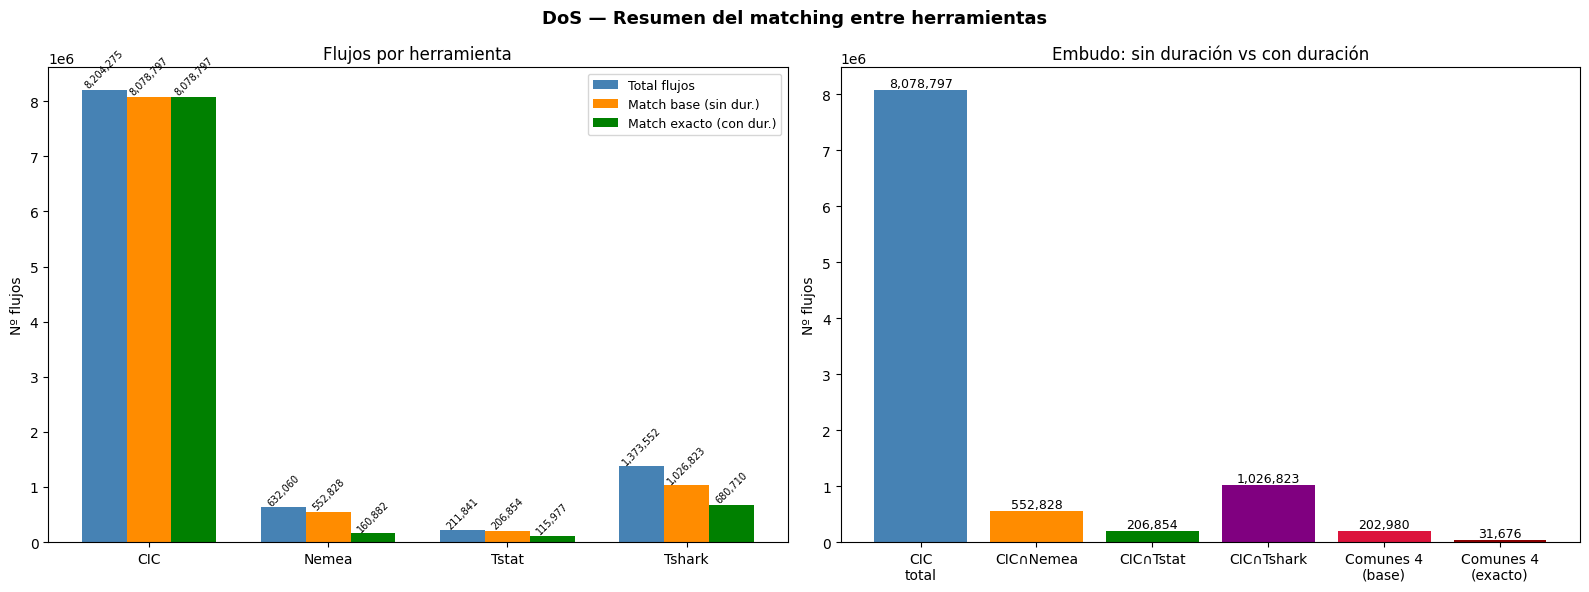

In [15]:
# ============================================================
# CELDA 5.2 — GRÁFICA RESUMEN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('DoS — Resumen del matching entre herramientas',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
herramientas = ['CIC', 'Nemea', 'Tstat', 'Tshark']
totales = [len(df_cic_keys), len(df_nemea_keys), len(df_tstat_base_k), len(df_tshark_keys)]
base    = [len(cic_keys_base), len(match_nemea_base), len(match_tstat_base), len(match_tshark_base)]
exactos = [len(cic_keys_base), len(match_nemea_exact), len(match_tstat_exact), len(match_tshark_exact)]

x, width = np.arange(len(herramientas)), 0.25
b1 = ax1.bar(x - width, totales, width, label='Total flujos',            color='steelblue')
b2 = ax1.bar(x,         base,    width, label='Match base (sin dur.)',   color='darkorange')
b3 = ax1.bar(x + width, exactos, width, label='Match exacto (con dur.)', color='green')
ax1.set_title('Flujos por herramienta')
ax1.set_ylabel('N\u00ba flujos')
ax1.set_xticks(x)
ax1.set_xticklabels(herramientas)
ax1.legend(fontsize=9)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h,
                 f'{h:,}', ha='center', va='bottom', fontsize=7, rotation=45)

ax2 = axes[1]
labels2 = ['CIC\ntotal','CIC\u2229Nemea','CIC\u2229Tstat','CIC\u2229Tshark','Comunes 4\n(base)','Comunes 4\n(exacto)']
values2 = [len(cic_keys_base), len(match_nemea_base), len(match_tstat_base),
           len(match_tshark_base), len(base_4), len(exact_4)]
colors2 = ['steelblue','darkorange','green','purple','crimson','darkred']
bars2 = ax2.bar(labels2, values2, color=colors2)
ax2.set_title('Embudo: sin duración vs con duración')
ax2.set_ylabel('N\u00ba flujos')
for bar, val in zip(bars2, values2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Extracción final — FASE 2 (chunked)
Una vez conocemos `base_4`, releemos cada CSV en trozos y extraemos solo las filas que matchean.
**Nunca se carga el fichero completo en RAM.**

In [16]:
# ============================================================
# CELDA 6.1 — FASE 2: EXTRACCIÓN CIC (chunked incremental)
# ============================================================

OUTPUT_DIR = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DoS')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cic_match_keys = set(df_cic_keys.loc[df_cic_keys['key_base'].isin(base_4), 'key_base'])
print(f'Claves CIC a extraer: {len(cic_match_keys):,}')

out_cic = OUTPUT_DIR / 'CIC_comunes.csv'
if out_cic.exists():
    out_cic.unlink()

total_escritas   = 0
claves_escritas  = set()   # deduplicar entre chunks y entre ficheros
primer_chunk     = True

for f in csv_files_cic:
    n_chunk = 0
    for chunk in pd.read_csv(f, chunksize=CHUNKSIZE, low_memory=False):
        chunk['Timestamp'] = (
            chunk['Timestamp'].astype(str)
            .str.replace(' p. m.', ' PM', regex=False)
            .str.replace(' a. m.', ' AM', regex=False)
            .str.strip()
        )
        chunk['Timestamp']      = pd.to_datetime(chunk['Timestamp'], format='%d/%m/%Y %I:%M:%S %p', errors='coerce')
        chunk                   = chunk.dropna(subset=['Timestamp'])
        chunk['Protocol']       = pd.to_numeric(chunk['Protocol'],      errors='coerce').fillna(0).astype(int)
        chunk['Src Port']       = pd.to_numeric(chunk['Src Port'],      errors='coerce').fillna(0).astype(int)
        chunk['Dst Port']       = pd.to_numeric(chunk['Dst Port'],      errors='coerce').fillna(0).astype(int)
        chunk['Flow Duration']  = pd.to_numeric(chunk['Flow Duration'], errors='coerce')
        chunk['time_sec']       = chunk['Timestamp'].dt.floor('s')
        chunk['_kb']            = list(zip(
            chunk['Src IP'].astype(str),   chunk['Src Port'].astype(str),
            chunk['Dst IP'].astype(str),   chunk['Dst Port'].astype(str),
            chunk['Protocol'].astype(str), chunk['time_sec'].astype(str)
        ))

        matched = chunk[chunk['_kb'].isin(cic_match_keys) & ~chunk['_kb'].isin(claves_escritas)].copy()
        if len(matched) > 0:
            matched = matched.sort_values('Flow Duration', ascending=False, na_position='last')
            matched = matched.drop_duplicates(subset=['_kb'], keep='first')
            claves_escritas.update(matched['_kb'].tolist())
            matched = matched.drop(columns=['time_sec', '_kb'], errors='ignore')
            matched.to_csv(out_cic, mode='a', index=False, header=primer_chunk)
            primer_chunk   = False
            total_escritas += len(matched)

        n_chunk += 1

    print(f'  {f.name}: {n_chunk} chunks  |  acumuladas: {total_escritas:,}')
    gc.collect()

print(f'\n✓ CIC extraído: {total_escritas:,} filas → {out_cic.name}')
df_cic_4 = pd.read_csv(out_cic, low_memory=False)
print(f'  Verificación: {len(df_cic_4):,} filas x {df_cic_4.shape[1]} columnas')

Claves CIC a extraer: 202,980
  DoS-HTTP_Flood.pcap_Flow.csv: 5 chunks  |  acumuladas: 56,915
  DoS-HTTP_Flood1.pcap_Flow.csv: 4 chunks  |  acumuladas: 56,915
  DoS-SYN_Flood.pcap_Flow.csv: 20 chunks  |  acumuladas: 135,213
  DoS-TCP_Flood.pcap_Flow.csv: 9 chunks  |  acumuladas: 136,030
  DoS-UDP_Flood.pcap_Flow.csv: 5 chunks  |  acumuladas: 202,980

✓ CIC extraído: 202,980 filas → CIC_comunes.csv
  Verificación: 202,980 filas x 84 columnas


In [ ]:
# ============================================================
# CELDA 6.2 — FASE 2: EXTRACCIÓN NEMEA (chunked incremental)
# Reconstruye las claves dentro de cada chunk igual que en Fase 1
# ============================================================

out_nemea      = OUTPUT_DIR / 'Nemea_comunes.csv'
if out_nemea.exists():
    out_nemea.unlink()

total_escritas  = 0
claves_escritas = set()
primer_chunk    = True

for f in csv_files_nemea:
    n_chunk = 0
    for chunk in pd.read_csv(f, chunksize=CHUNKSIZE, low_memory=False):

        # Normalizar IPs
        chunk[col_src_ip] = chunk[col_src_ip].astype(str).str.strip()
        chunk[col_dst_ip] = chunk[col_dst_ip].astype(str).str.strip()
        chunk['SRC_IP_norm'] = chunk[col_src_ip].apply(reconstruir_ip)
        chunk['DST_IP_norm'] = chunk[col_dst_ip].apply(reconstruir_ip)

        # Timestamp
        chunk['TIME_FIRST_limpio'] = chunk[col_t_first].astype(str).str.replace(',', '.', regex=False)
        chunk['TIME_FIRST_dt']     = pd.to_datetime(chunk['TIME_FIRST_limpio'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce')
        chunk['TIME_FIRST_utc2']   = chunk['TIME_FIRST_dt'] + pd.Timedelta(hours=2)
        chunk['time_sec']          = chunk['TIME_FIRST_utc2'].dt.floor('s')

        # Protocolo
        chunk[col_protocol] = pd.to_numeric(chunk[col_protocol], errors='coerce').fillna(0).astype(int)

        # Claves dir e inv
        chunk['_kb_dir'] = list(zip(
            chunk['SRC_IP_norm'].astype(str), chunk[col_src_port].astype(str),
            chunk['DST_IP_norm'].astype(str), chunk[col_dst_port].astype(str),
            chunk[col_protocol].astype(str),  chunk['time_sec'].astype(str)
        ))
        chunk['_kb_inv'] = list(zip(
            chunk['DST_IP_norm'].astype(str), chunk[col_dst_port].astype(str),
            chunk['SRC_IP_norm'].astype(str), chunk[col_src_port].astype(str),
            chunk[col_protocol].astype(str),  chunk['time_sec'].astype(str)
        ))

        # Asignar _key canónica (la que está en base_4)
        chunk['_key'] = None
        m_dir = chunk['_kb_dir'].isin(base_4)
        m_inv = chunk['_kb_inv'].isin(base_4)
        chunk.loc[m_dir, '_key'] = chunk.loc[m_dir, '_kb_dir']
        chunk.loc[m_inv & chunk['_key'].isna(), '_key'] = chunk.loc[m_inv & chunk['_key'].isna(), '_kb_inv']

        matched = chunk[chunk['_key'].isin(base_4) & ~chunk['_key'].isin(claves_escritas)].copy()
        if len(matched) > 0:
            matched = matched.drop_duplicates(subset=['_key'], keep='first')
            claves_escritas.update(matched['_key'].tolist())
            cols_drop = ['SRC_IP_norm','DST_IP_norm','TIME_FIRST_limpio',
                         'TIME_FIRST_dt','TIME_FIRST_utc2','time_sec',
                         '_kb_dir','_kb_inv','_key']
            matched = matched.drop(columns=cols_drop, errors='ignore')
            matched.to_csv(out_nemea, mode='a', index=False, header=primer_chunk)
            primer_chunk   = False
            total_escritas += len(matched)

        n_chunk += 1

    print(f'  {f.name}: {n_chunk} chunks  |  acumuladas: {total_escritas:,}')
    gc.collect()

print(f'\n✓ Nemea extraído: {total_escritas:,} filas → {out_nemea.name}')
df_nemea_4 = pd.read_csv(out_nemea, low_memory=False)
print(f'  Verificación: {len(df_nemea_4):,} filas x {df_nemea_4.shape[1]} columnas')